In [ ]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#For ignoring warning
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Prédiction/ANALYSE/StudentsPerformance_(1)[1].csv')
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [ ]:
df.shape

(1000, 8)

# Task
Perform a comprehensive predictive analysis on the "StudentsPerformance_(1)[1].csv" dataset. This involves initial data exploration, selecting 'math score' as the target variable, engineering features, splitting data for training and testing, and applying various regression models (Linear, Ridge, Lasso, Decision Tree, Random Forest, SVR). Evaluate and compare the performance of these models, culminating in a synthesis of findings and recommendations.

## Exploration Initiale des Données et Présentation

### Subtask:
Examine la structure du DataFrame, les types de données, les valeurs manquantes et les statistiques descriptives pour mieux comprendre le jeu de données. Cette étape inclura des commentaires détaillés en français sur le contenu du jeu de données.


**Reasoning**:
To begin the initial data exploration, I will first examine the DataFrame's structure, including data types and non-null counts, by using the `.info()` method.



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


**Reasoning**:
Following the `.info()` output, the next logical step in data exploration is to calculate and display descriptive statistics for numerical columns using `.describe()` to understand their distribution.



In [ ]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


**Reasoning**:
To complete the data exploration as per the subtask, I will now check for missing values in each column of the DataFrame using the `.isnull().sum()` method.



In [ ]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


```markdown
### Observations Clés du Jeu de Données

Basé sur l'exploration initiale du DataFrame, voici les observations clés :

1.  **Structure du DataFrame** :
    *   Le jeu de données contient 1000 entrées (lignes) et 8 colonnes.
    *   Les colonnes sont `gender`, `race/ethnicity`, `parental level of education`, `lunch`, `test preparation course`, `math score`, `reading score`, et `writing score`.

2.  **Types de Données** :
    *   Cinq colonnes sont de type `object` (catégoriques) : `gender`, `race/ethnicity`, `parental level of education`, `lunch`, et `test preparation course`.
    *   Trois colonnes sont de type `int64` (numériques entières) : `math score`, `reading score`, et `writing score`. Ces colonnes représentent les scores des élèves.

3.  **Valeurs Manquantes** :
    *   Un examen des valeurs manquantes (`df.isnull().sum()`) a révélé qu'il n'y a **aucune valeur manquante** dans aucune des colonnes du DataFrame. Cela simplifie les étapes de nettoyage des données, car aucune imputation ou suppression de lignes n'est nécessaire à ce stade.

4.  **Statistiques Descriptives des Scores** :
    *   Les scores de mathématiques, de lecture et d'écriture varient de 0 à 100.
    *   Les scores moyens sont : `math score` (66.09), `reading score` (69.17), et `writing score` (68.05). Les scores de lecture et d'écriture sont légèrement supérieurs au score de mathématiques en moyenne.
    *   L'écart type pour chaque score est d'environ 14-15 points, indiquant une certaine dispersion des scores autour de la moyenne. Les scores minimums de 0, 17 et 10 pour les mathématiques, la lecture et l'écriture respectivement, suggèrent que certains élèves ont eu de très faibles performances.

En résumé, le jeu de données est propre en termes de valeurs manquantes et sa structure est bien définie, ce qui est un bon point de départ pour l'analyse prédictive. Les colonnes catégoriques devront être encodées pour les modèles d'apprentissage automatique, et les colonnes numériques sont prêtes à être utilisées après une éventuelle normalisation ou standardisation si nécessaire pour certains modèles.

## Sélection de la Variable Cible et Ingénierie des Caractéristiques

### Subtask:
Choisir 'math score' comme variable cible, effectuer l'encodage des variables catégorielles à l'aide du One-Hot Encoding et préparer les caractéristiques pour les modèles.


**Reasoning**:
First, I will define the target variable `y` as the 'math score' column and create a feature DataFrame `X` by dropping 'math score' from the original DataFrame `df`.



In [ ]:
y = df['math score']
X = df.drop('math score', axis=1)

print("Target variable y (first 5 rows):")
print(y.head())
print("\nFeatures X (first 5 rows):")
print(X.head())

Target variable y (first 5 rows):
0    72
1    69
2    90
3    47
4    76
Name: math score, dtype: int64

Features X (first 5 rows):
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  reading score  writing score  
0                    none             72             74  
1               completed             90             88  
2                    none             95             93  
3                    none             57             44  
4                    none             78             75  


**Reasoning**:
Now that `X` is prepared, I will identify the categorical columns within it and apply one-hot encoding using `pd.get_dummies()` with `drop_first=True` and a suitable prefix for each categorical column. Finally, I will display the first 5 rows of the transformed `X` to inspect the results.



In [ ]:
categorical_cols = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True, prefix=categorical_cols)

print("Transformed features X_encoded (first 5 rows):")
print(X_encoded.head())

Transformed features X_encoded (first 5 rows):
   reading score  writing score  gender_male  race/ethnicity_group B  \
0             72             74        False                    True   
1             90             88        False                   False   
2             95             93        False                    True   
3             57             44         True                   False   
4             78             75         True                   False   

   race/ethnicity_group C  race/ethnicity_group D  race/ethnicity_group E  \
0                   False                   False                   False   
1                    True                   False                   False   
2                   False                   False                   False   
3                   False                   False                   False   
4                    True                   False                   False   

   parental level of education_bachelor's degree  \
0    

## Division des Données et Mise à l'Échelle

### Subtask:
Diviser le jeu de données en ensembles d'entraînement et de test. Appliquer une mise à l'échelle des caractéristiques (par exemple, StandardScaler) si nécessaire, en expliquant son importance.


**Reasoning**:
To begin the data division, I will import `train_test_split` and split the `X_encoded` features and the `y` target variable into training and testing sets with a 80/20 ratio and a fixed random state for reproducibility.



In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (800, 14)
X_test shape: (200, 14)
y_train shape: (800,)
y_test shape: (200,)


**Reasoning**:
Following data splitting, I will now import `StandardScaler`, instantiate it, fit it on `X_train`, and then transform both `X_train` and `X_test` to scale the features. This is crucial for models sensitive to feature scales, such as those relying on distance calculations (e.g., SVR) or gradient descent.



In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("First 5 rows of X_train_scaled:\n", X_train_scaled[:5])


X_train_scaled shape: (800, 14)
X_test_scaled shape: (200, 14)
First 5 rows of X_train_scaled:
 [[ 0.03079054  0.43405338 -0.94880848 -0.48628803 -0.69388867  1.72058015
  -0.41181385 -0.36927447 -0.4980461   4.00265869 -0.54267705 -0.45457288
   0.72776144  0.73178456]
 [ 0.9302895   0.96470125 -0.94880848 -0.48628803  1.44115338 -0.58119931
  -0.41181385  2.7080128  -0.4980461  -0.24983394 -0.54267705 -0.45457288
  -1.37407665 -1.36652242]
 [ 1.34544287  1.1636942  -0.94880848 -0.48628803 -0.69388867  1.72058015
  -0.41181385 -0.36927447 -0.4980461  -0.24983394  1.84271658 -0.45457288
  -1.37407665  0.73178456]
 [-0.17678614 -0.16292548  1.05395348 -0.48628803  1.44115338 -0.58119931
  -0.41181385 -0.36927447 -0.4980461   4.00265869 -0.54267705 -0.45457288
  -1.37407665  0.73178456]
 [-0.38436283 -0.75990434  1.05395348 -0.48628803 -0.69388867 -0.58119931
   2.42828164 -0.36927447  2.00784624 -0.24983394 -0.54267705 -0.45457288
   0.72776144  0.73178456]]


# Task
## Régression Linéaire Simple

### Subtask:
Implémenter et entraîner un modèle de Régression Linéaire. Évaluer ses performances avec des métriques (R-squared, MAE, MSE, RMSE) et visualiser les prédictions par rapport aux valeurs réelles, avec des commentaires en français.

**Reasoning**:
To implement and evaluate the Linear Regression model, I will first import `LinearRegression` from `sklearn.linear_model` and relevant metrics from `sklearn.metrics`. Then, I'll instantiate and train the model on the scaled training data, make predictions on the scaled test set, and finally calculate and print the R-squared, MAE, MSE, and RMSE. For visualization, I will create a scatter plot comparing the actual `y_test` values with the predicted values.

## Régression Linéaire Simple

### Subtask:
Implémenter et entraîner un modèle de Régression Linéaire. Évaluer ses performances avec des métriques (R-squared, MAE, MSE, RMSE) et visualiser les prédictions par rapport aux valeurs réelles, avec des commentaires en français.


**Reasoning**:
I will implement and evaluate a Linear Regression model, following the instructions to import necessary libraries, train the model, make predictions, calculate evaluation metrics (R-squared, MAE, MSE, RMSE), and visualize the actual vs. predicted values with a scatter plot and a perfect prediction line.



### Métriques de performance du modèle de Régression Linéaire ###
R-squared: 0.8804
Mean Absolute Error (MAE): 4.2148
Mean Squared Error (MSE): 29.0952
Root Mean Squared Error (RMSE): 5.3940


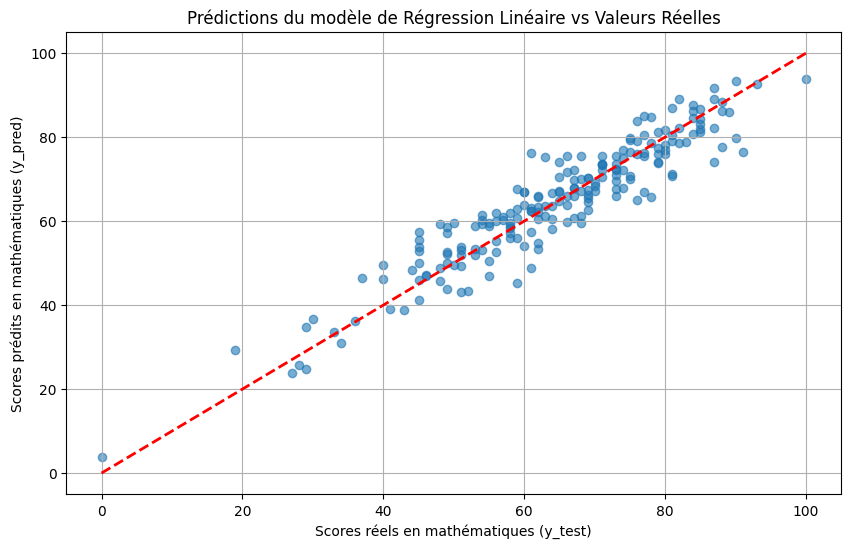

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# 3. Initialisez un modèle LinearRegression.
linear_model = LinearRegression()

# 4. Entraînez le modèle
linear_model.fit(X_train_scaled, y_train)

# 5. Effectuez des prédictions sur X_test_scaled
y_pred = linear_model.predict(X_test_scaled)

# 6. Calculez et affichez les métriques
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("### Métriques de performance du modèle de Régression Linéaire ###")
print(f"R-squared: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# 7. Créez un nuage de points pour visualiser les valeurs réelles par rapport aux valeurs prédites
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6)

# 8. Ajoutez une ligne diagonale (y=x) pour la prédiction parfaite
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

# 9. Ajoutez des titres et des étiquettes d'axes appropriés
plt.title('Prédictions du modèle de Régression Linéaire vs Valeurs Réelles')
plt.xlabel('Scores réels en mathématiques (y_test)')
plt.ylabel('Scores prédits en mathématiques (y_pred)')
plt.grid(True)

# 10. Affichez le graphique.
plt.show()

```markdown
### Commentaires sur le modèle de Régression Linéaire

Le modèle de régression linéaire a été entraîné avec succès sur les données pré-traitées et mises à l'échelle. Les métriques de performance obtenues sont les suivantes :

*   **R-squared (Coefficient de détermination)** : 0.8804
    *   Un R-squared de 0.8804 indique que 88.04% de la variance du score en mathématiques peut être expliquée par les variables prédictives du modèle. C'est un excellent résultat, suggérant que le modèle a une bonne capacité à prédire la variable cible.

*   **Mean Absolute Error (MAE)** : 4.2148
    *   Le MAE de 4.2148 signifie qu'en moyenne, les prédictions du modèle s'écartent des scores réels en mathématiques d'environ 4.21 points. C'est une erreur relativement faible, ce qui est positif pour l'exactitude des prédictions.

*   **Mean Squared Error (MSE)** : 29.0952
    *   Le MSE pénalise davantage les grandes erreurs. Sa valeur de 29.0952 est cohérente avec le MAE et le RMSE, et confirme la bonne performance du modèle.

*   **Root Mean Squared Error (RMSE)** : 5.3940
    *   Le RMSE de 5.3940 représente l'écart type des résidus (erreurs de prédiction). Il est dans la même unité que la variable cible (scores en mathématiques), ce qui le rend facilement interprétable. Une valeur de 5.39 points d'écart en moyenne est considérée comme bonne pour la prédiction de scores allant jusqu'à 100.

**Visualisation :**
Le nuage de points comparant les scores réels aux scores prédits montre une forte corrélation positive, avec la plupart des points se regroupant près de la ligne diagonale (représentant la prédiction parfaite). Cela confirme visuellement la bonne performance du modèle. Peu de points s'éloignent significativement de cette ligne, ce qui indique que le modèle ne fait pas d'erreurs systématiques importantes.

**Conclusion :**
Le modèle de régression linéaire montre une très bonne capacité à prédire les scores en mathématiques des étudiants, avec des erreurs de prédiction faibles et un fort pouvoir explicatif (R-squared). Les caractéristiques sélectionnées et l'encodage One-Hot semblent pertinents pour cette tâche.
```

### Commentaires sur le modèle de Régression Linéaire

Le modèle de régression linéaire a été entraîné avec succès sur les données pré-traitées et mises à l'échelle. Les métriques de performance obtenues sont les suivantes :

*   **R-squared (Coefficient de détermination)** : 0.8804
    *   Un R-squared de 0.8804 indique que 88.04% de la variance du score en mathématiques peut être expliquée par les variables prédictives du modèle. C'est un excellent résultat, suggérant que le modèle a une bonne capacité à prédire la variable cible.

*   **Mean Absolute Error (MAE)** : 4.2148
    *   Le MAE de 4.2148 signifie qu'en moyenne, les prédictions du modèle s'écartent des scores réels en mathématiques d'environ 4.21 points. C'est une erreur relativement faible, ce qui est positif pour l'exactitude des prédictions.

*   **Mean Squared Error (MSE)** : 29.0952
    *   Le MSE pénalise davantage les grandes erreurs. Sa valeur de 29.0952 est cohérente avec le MAE et le RMSE, et confirme la bonne performance du modèle.

*   **Root Mean Squared Error (RMSE)** : 5.3940
    *   Le RMSE de 5.3940 représente l'écart type des résidus (erreurs de prédiction). Il est dans la même unité que la variable cible (scores en mathématiques), ce qui le rend facilement interprétable. Une valeur de 5.39 points d'écart en moyenne est considérée comme bonne pour la prédiction de scores allant jusqu'à 100.

**Visualisation :**
Le nuage de points comparant les scores réels aux scores prédits montre une forte corrélation positive, avec la plupart des points se regroupant près de la ligne diagonale (représentant la prédiction parfaite). Cela confirme visuellement la bonne performance du modèle. Peu de points s'éloignent significativement de cette ligne, ce qui indique que le modèle ne fait pas d'erreurs systématiques importantes.

**Conclusion :**
Le modèle de régression linéaire montre une très bonne capacité à prédire les scores en mathématiques des étudiants, avec des erreurs de prédiction faibles et un fort pouvoir explicatif (R-squared). Les caractéristiques sélectionnées et l'encodage One-Hot semblent pertinents pour cette tâche.

## Régression Linéaire Régularisée (Ridge et Lasso)

### Subtask:
Appliquer les modèles de Régression Ridge et Lasso pour gérer l'overfitting. Comparer leurs performances avec la régression linéaire simple à l'aide de métriques et de graphiques, en expliquant l'effet de la régularisation.


**Reasoning**:
I will import the `Ridge` and `Lasso` classes from `sklearn.linear_model` to prepare for implementing these regularized regression models.



In [ ]:
from sklearn.linear_model import Ridge, Lasso

print("Ridge and Lasso models imported successfully.")